In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures

### Création de données

C:\Users\proma\AppData\Local\Temp\ipykernel_57104\3123808686.py:15: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
C:\Users\proma\AppData\Local\Temp\ipykernel_57104\3123808686.py:18: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X2 = np.random.multivariate_normal(mean = mean2, cov=cov2, size=100)


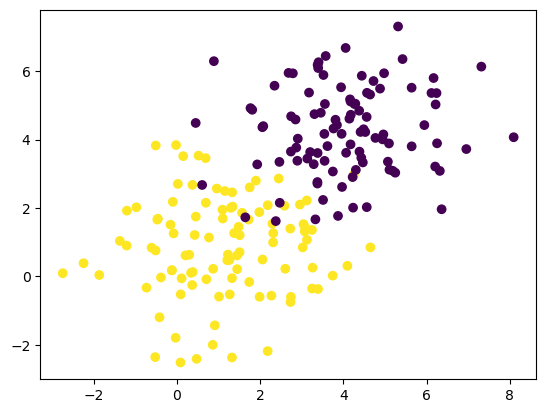

In [316]:
np.random.seed(0)

mean1 = [1, 1]
mean2 = [4, 4]

cov1 = [
    [0.1, 2],
    [2, 0.1]
]
cov2 = [
    [0.1, 2],
    [2, 0.1]
]

X1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
X1 = np.concatenate([X1, np.ones((len(X1), 1))], axis=1)

X2 = np.random.multivariate_normal(mean = mean2, cov=cov2, size=100)
X2 = np.concatenate([X2, np.zeros((len(X2), 1))], axis=1)

data = np.concatenate([X1, X2], axis=0)

plt.figure()
plt.scatter(data[:, 0], data[:, 1], c=data[:, -1])

In [318]:
data.shape

(200, 3)

### Train_test_split

In [321]:
X_train, X_test, Y_train, Y_test = train_test_split(data[:, :-1], data[:, -1], test_size=0.2, random_state=42, shuffle=True)

### Model training

In [324]:
lgr = LogisticRegression()

In [326]:
lgr.fit(X_train, Y_train)

LogisticRegression()

In [328]:
lgr.score(X_test, Y_test)

1.0

### Visualisation de nos prédictions

In [331]:
absx = np.linspace(X_test[:, 0].min(), X_test[:, 0].max(), len(X_test[:, 0]))

#### Nos vraies classes :

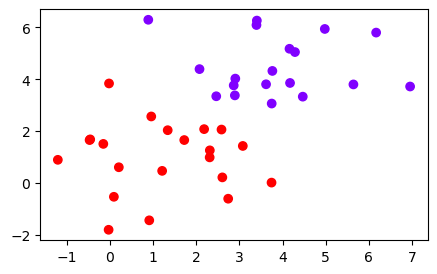

In [337]:
plt.figure(figsize=(5, 3))
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, cmap='rainbow')

#### Les classes prédites :

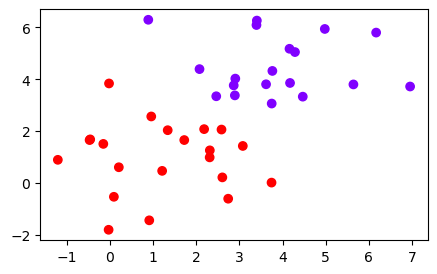

In [343]:
plt.figure(figsize=(5, 3))
plt.scatter(X_test[:, 0], X_test[:, 1], c=lgr.predict(X_test), cmap='rainbow')

### Frontière de décision

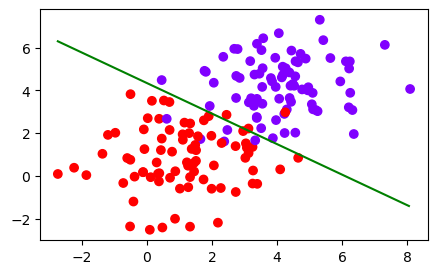

In [348]:
# On a extrait les coefficients optimaux de la droite de la frontière de décision

w0 = lgr.intercept_
w1, w2 = lgr.coef_[0]

xmin, xmax = X_train[:, 0].min(), X_train[:, 0].max()
ymin, ymax = X_train[:, 1].min(), X_train[:, 1].max()
Absx = np.arange(xmin, xmax, 0.1)

plt.figure(figsize=(5, 3))
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap='rainbow')
plt.plot(Absx, -(w0 + w1 * Absx) / w2, c='green')
# La fonction a cette forme car la fonction de la frontière de décision est sous forme cartésienne.
# En effet, on a Z = w0 + w1*X1 + w2*X2

### One Against All Method

C:\Users\proma\AppData\Local\Temp\ipykernel_57104\3479190455.py:21: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
C:\Users\proma\AppData\Local\Temp\ipykernel_57104\3479190455.py:22: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X2 = np.random.multivariate_normal(mean = mean2, cov=cov2, size=100)
C:\Users\proma\AppData\Local\Temp\ipykernel_57104\3479190455.py:23: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X3 = np.random.multivariate_normal(mean = mean3, cov=cov3, size=100)


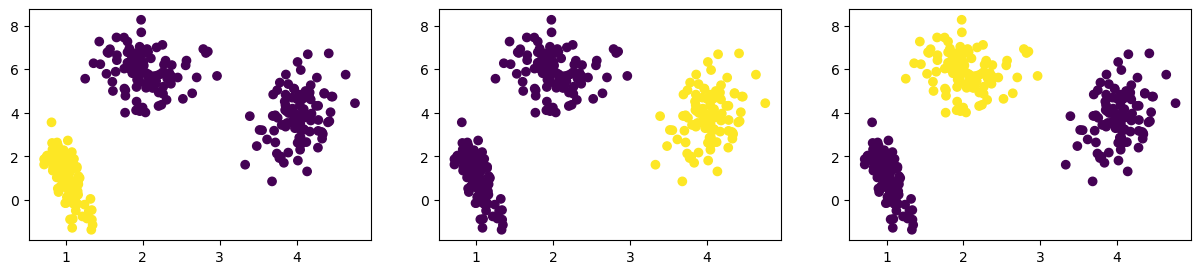

In [351]:
np.random.seed(0)

mean1 = [1, 1]
mean2 = [4, 4]
mean3 = [2, 6]

cov1 = [
    [0.1, -1],
    [0, 0.1]
]
cov2 = [
    [0.1, 1],
    [0, 1]
]

cov3 = [
    [0.1, -0.1],
    [0, 0.7]
]

X1 = np.random.multivariate_normal(mean=mean1, cov=cov1, size=100)
X2 = np.random.multivariate_normal(mean = mean2, cov=cov2, size=100)
X3 = np.random.multivariate_normal(mean = mean3, cov=cov3, size=100)

dataset1 = np.concatenate(
    [np.concatenate([X1, np.ones((len(X1), 1))], axis=1), np.concatenate([X2, np.zeros((len(X2), 1))], axis=1), np.concatenate([X3, np.zeros((len(X3), 1))], axis=1)], 
    axis=0
)

dataset2 = np.concatenate(
    [np.concatenate([X1, np.zeros((len(X1), 1))], axis=1), np.concatenate([X2, np.ones((len(X2), 1))], axis=1), np.concatenate([X3, np.zeros((len(X3), 1))], axis=1)], 
    axis=0
)

dataset3 = np.concatenate(
    [np.concatenate([X1, np.zeros((len(X1), 1))], axis=1), np.concatenate([X2, np.zeros((len(X2), 1))], axis=1), np.concatenate([X3, np.ones((len(X3), 1))], axis=1)], 
    axis=0
)

fig, axs = plt.subplots(1, 3, figsize=(15, 3))
axs[0].scatter(dataset1[:, 0], dataset1[:, 1], c=dataset1[:, 2])
axs[1].scatter(dataset2[:, 0], dataset2[:, 1], c=dataset2[:, 2])
axs[2].scatter(dataset3[:, 0], dataset3[:, 1], c=dataset3[:, 2])

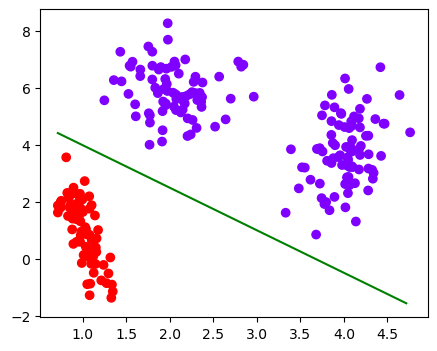

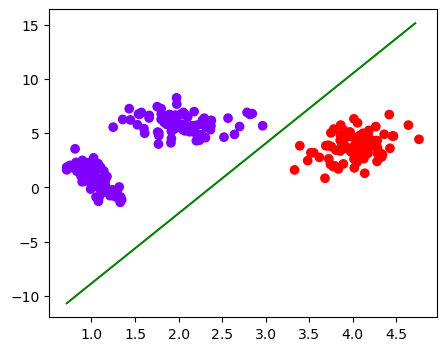

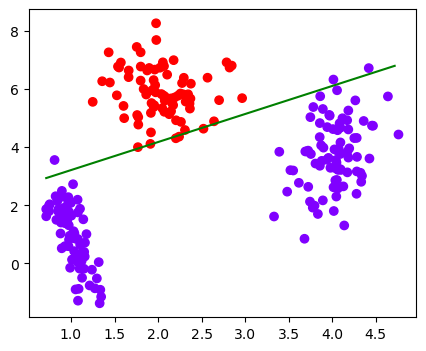

In [353]:
biais = []
coeffs = []

for data in [dataset1, dataset2, dataset3]:
    X_train2, X_test2, Y_train2, Y_test2 = train_test_split(data[:, :-1], data[:, -1], test_size=0.2, random_state=42, shuffle=True)
    
    lgr2 = LogisticRegression()
    lgr2.fit(X_train2, Y_train2)
    
    # On a extrait les coefficients optimaux de la droite de la frontière de décision
    w0 = lgr2.intercept_
    w1, w2 = lgr2.coef_[0]

    biais.append(w0)
    coeffs.append([w1, w2])
    
    xmin, xmax = X_train2[:, 0].min(), X_train2[:, 0].max()
    ymin, ymax = X_train2[:, 1].min(), X_train2[:, 1].max()
    Absx = np.arange(xmin, xmax, 0.1)
    
    plt.figure(figsize=(5, 4))
    plt.scatter(X_train2[:, 0], X_train2[:, 1], c=Y_train2, cmap='rainbow')
    plt.plot(Absx, -(w0 + w1 * Absx) / w2, c='green')



### Tracé des 3 frontières

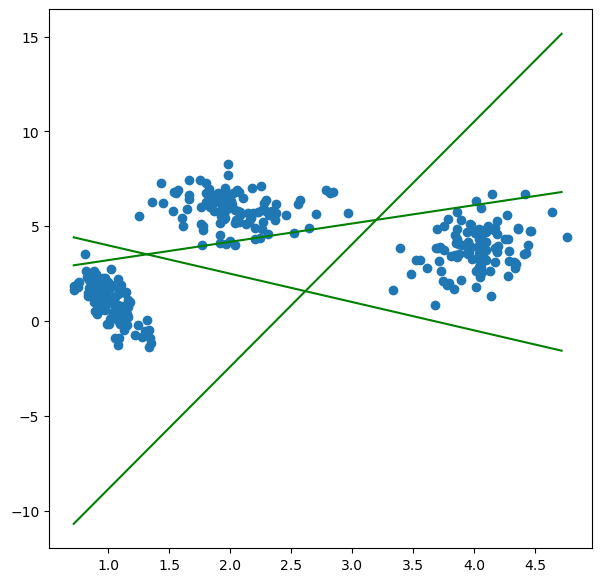

In [356]:
xmin, xmax = dataset1[:, 0].min(), dataset1[:, 0].max()
ymin, ymax = dataset1[:, 1].min(), dataset1[:, 1].max()
Absx = np.arange(xmin, xmax, 0.1)

plt.figure(figsize=(7, 7))
plt.scatter(dataset1[:, 0], dataset1[:, 1])
for i, j in zip(biais, coeffs):
    plt.plot(Absx, -(i + j[0]* Absx) / j[1], c='green')

## Régression logistique avec SkLearn et Dataset Iris

In [2]:
from sklearn.datasets import load_iris

#### Data loading

In [4]:
X_iris = load_iris(as_frame=True).data
Y_iris = load_iris(as_frame=True).target
X_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


#### Feature Engineering

In [6]:
pipeline = Pipeline([
    ('std', StandardScaler()),
    ('lgr', LogisticRegression(penalty=None, multi_class='multinomial', solver='saga', max_iter=5000))
])

#### Split data

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X_iris, Y_iris, test_size=0.30, random_state=42, shuffle=True)

### Grid Search CV

In [74]:
param_grid = [
    {
    'lgr__penalty' : ['l1'],
    'lgr__multi_class' : ['ovr', 'multinomial'],
    'lgr__solver' : ['saga'],
    'lgr__max_iter' : [1000, 5000, 10000]
    }, 
    {
    'lgr__penalty': ['elasticnet'],
    'lgr__multi_class': ['ovr', 'multinomial'],
    'lgr__solver': ['saga'],  # seul solver compatible elasticnet
    'lgr__l1_ratio': [0.1, 0.5, 0.9],
    'lgr__max_iter': [1000, 5000, 10000]
    },
    {
    'lgr__penalty': ['l2'],
    'lgr__multi_class': ['ovr', 'multinomial'],
    'lgr__solver': ['saga', 'lbfgs', 'sag'],
    'lgr__max_iter': [1000, 5000, 10000]
    }
]

In [76]:
grid = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = 'accuracy',
    cv = StratifiedKFold(n_splits=3),
    n_jobs = 6
)

In [78]:
grid.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('std', StandardScaler()),
                                       ('lgr',
                                        LogisticRegression(max_iter=5000,
                                                           multi_class='multinomial',
                                                           penalty=None,
                                                           solver='saga'))]),
             n_jobs=6,
             param_grid=[{'lgr__max_iter': [1000, 5000, 10000],
                          'lgr__multi_class': ['ovr', 'multinomial'],
                          'lgr__penalty': ['l1'], 'lgr__solver': ['saga']},
                         {'lgr__l1_ratio': [0.1, 0.5, 0.9],
                          'lgr__max_iter': [1000, 5000, 10000],
                          'lgr__multi_class': ['ovr', 'multinomial'],
                          'lgr__penalty': ['elasticnet'],
                          'lgr__solver': ['saga']},
                         {'lgr__max_iter': [1000, 5000, 10000],
                          'lgr__multi_class': ['ovr', 'multinomial'],
                          'lgr__penalty': ['l2'],
                          'lgr__solver': ['saga', 'lbfgs', 'sag']}],
             scoring='accuracy')

In [79]:
grid.best_params_

{'lgr__l1_ratio': 0.5,
 'lgr__max_iter': 1000,
 'lgr__multi_class': 'multinomial',
 'lgr__penalty': 'elasticnet',
 'lgr__solver': 'saga'}

In [82]:
grid.best_score_

0.942857142857143